In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as scp
from scipy import optimize
%matplotlib inline

In [124]:
dados = {
    "Evento": [
        "1500 m", "1500 m (indoor)", "One mile", "3000 m", "3000 m (indoor)", 
        "Two miles", "Two miles (indoor)", "5000 m", "5000 m (indoor)", 
        "10 000 m", "5 km", "10 km", "Half marathon", "30 km", "Marathon"
    ],
    # metros
    "Distancia_m": [
        1500.0, 1500.0, 1609.34, 3000.0, 3000.0, 
        3218.68, 3218.68, 5000.0, 5000.0, 
        10000.0, 5000.0, 10000.0, 21097.5, 30000.0, 42195.0
    ],
    # segundo
    "Tempo_s": [
        213.0, 216.0, 230.0, 448.0, 449.0, 
        488.0, 487.0, 767.0, 776.0, 
        1609.0, 791.0, 1691.0, 3565.0, 5233.0, 7299.0
    ],
    # metros/segundo
    "Velocidade_ms": [
        7.04, 6.94, 6.98, 6.70, 6.68, 
        6.60, 6.60, 6.52, 6.45, 
        6.21, 6.32, 5.91, 5.92, 5.73, 5.78
    ]
}
df = pd.DataFrame(dados)

df.rename(columns={"Tempo_s":"Tempo_h", "Velocidade_ms":"Velocidade_kmh","Distancia_m":"Distancia_km"},inplace=True)

df['Tempo_h'] = df['Tempo_h'] / 3600 # s → h
df['Distancia_km'] = df['Distancia_km'] / 1000 # m → km
df['Velocidade_kmh'] = df['Velocidade_kmh'] * 3.6 # m/s → km/h

tempos = df['Tempo_h'].values
velocidades = df['Velocidade_kmh'].values
distancias = df['Distancia_km'].values

In [125]:
def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

def modelo_potencia(T, S, E):
    return S * T**(E - 1.0)

def modelo_hyper(T, a, alpha,gamma):
    # Erro
    # return (a * T**alpha) / (T**alpha + gamma**alpha) + a 
    return (a * gamma**alpha) / (T**alpha + gamma**alpha)

In [126]:
# Chutes iniciais
p0_sig = [np.max(velocidades)-np.min(velocidades), 5.0, 0.5, np.min(velocidades)*0.8] # [ Diferença máxima entre as velocidades | ]
p0_pow = [27, 0.9]
p0_hyper = [20,-2,50]

# Executando os fittings
popt_sig, _ = optimize.curve_fit(modelo_sigmoide, tempos, velocidades, p0=p0_sig, maxfev=10000)
popt_pow, _ = optimize.curve_fit(modelo_potencia, tempos, velocidades, p0=p0_pow, maxfev=10000)
popt_hyper, _ = optimize.curve_fit(modelo_hyper, tempos, velocidades, p0=p0_hyper, maxfev=10000,bounds=([0,-10,0.001],[np.max(velocidades)*1.05,10,10000]))

# Cálculo dos resíduos e normas
erro_sig = velocidades - modelo_sigmoide(tempos, *popt_sig)
erro_pow = velocidades - modelo_potencia(tempos, *popt_pow)
erro_hyper = velocidades - modelo_hyper(tempos, *popt_hyper)

norma_sig = np.linalg.norm(erro_sig)
norma_pow = np.linalg.norm(erro_pow)
norma_hyper = np.linalg.norm(erro_hyper)

In [127]:
print("--- Parâmetros Fitados ---")

# Sigmóide: [Amplitude (A), k, t0, V_base]
print(f"Sigmóide:")
print(f"  Amplitude de queda: {popt_sig[0]:.3f} km/h")
print(f"  Taxa de decaimento (k): {popt_sig[1]:.5f}")
print(f"  Ponto de inflexão (t0): {popt_sig[2]:.1f} s")
print(f"  Velocidade Base (Assíntota): {popt_sig[3]:.3f} km/h\n")

# Lei de Potência (Riegel): [S, E]
print(f"Lei de Potência:")
print(f"  Velocidade Limite (S): {popt_pow[0]:.3f} km/h")
print(f"  Fator de Endurance (E): {popt_pow[1]:.4f}\n")

# Hyper: [a, alpha, gamma]
print(f"Hyper:")
print(f"  Velocidade Máxima (a): {popt_hyper[0]:.3f} km/h")
print(f"  Decaimento (alpha): {popt_hyper[1]:.4f}")
print(f"  Fator de escala (gamma): {popt_hyper[2]:.1f}")

--- Parâmetros Fitados ---
Sigmóide:
  Amplitude de queda: 234788.423 km/h
  Taxa de decaimento (k): 4.03075
  Ponto de inflexão (t0): -2.7 s
  Velocidade Base (Assíntota): 20.887 km/h

Lei de Potência:
  Velocidade Limite (S): 21.171 km/h
  Fator de Endurance (E): 0.9401

Hyper:
  Velocidade Máxima (a): 26.611 km/h
  Decaimento (alpha): 0.3893
  Fator de escala (gamma): 35.7


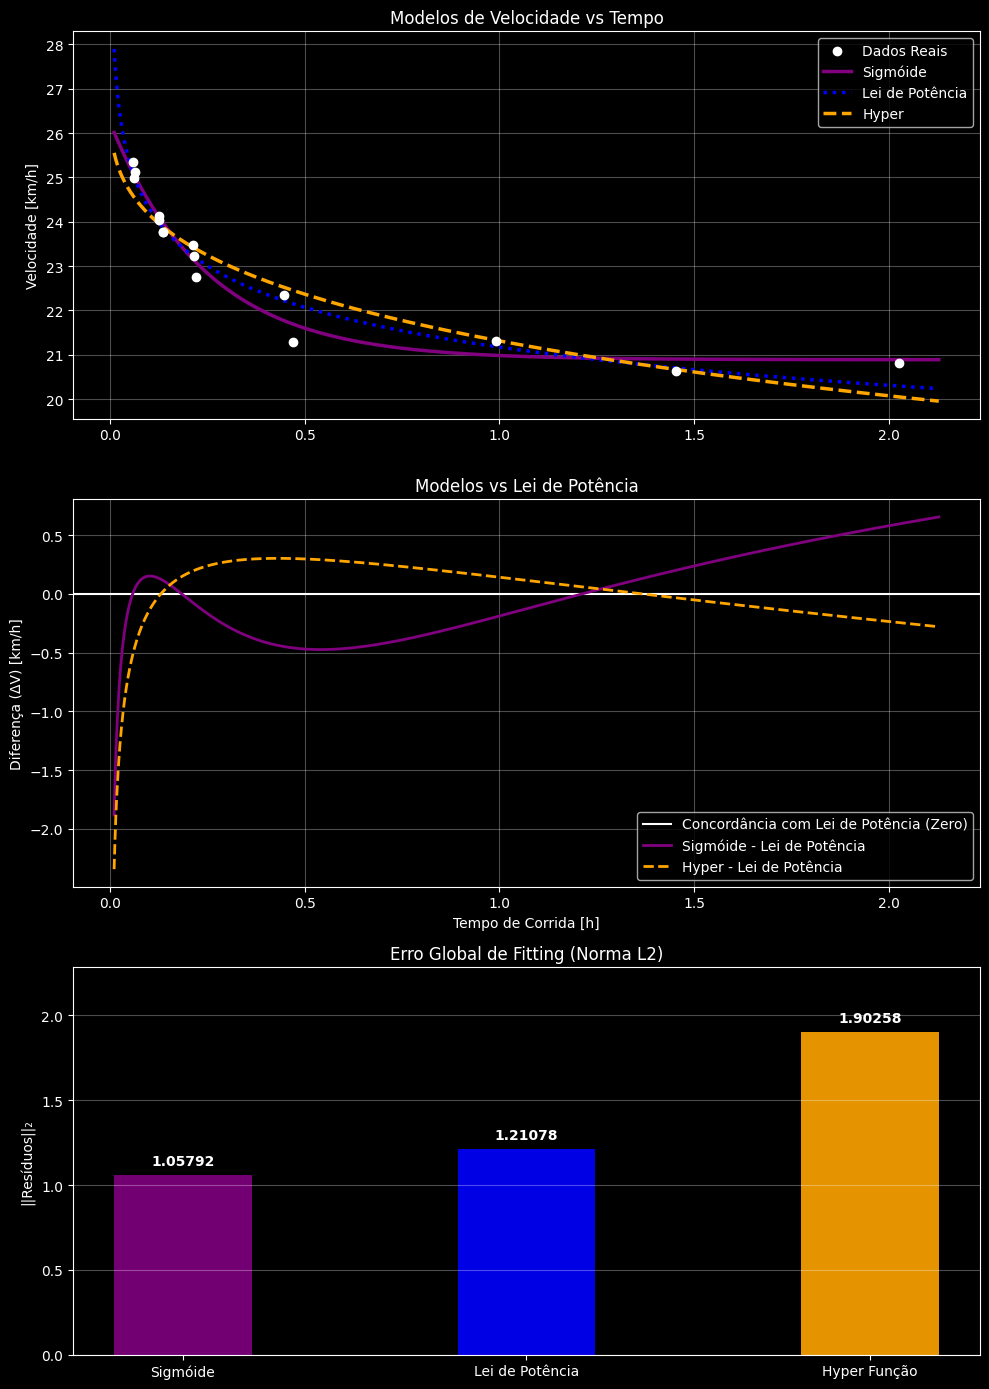

In [ ]:
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

# Geração das predições contínuas para plotagem
T_plot = np.linspace(0.01, np.max(tempos) * 1.05, 1000) # Tempos próximos de zero até um pouco após o máximo
pred_sig = modelo_sigmoide(T_plot, *popt_sig) # operador * antes de uma lista atribui cada elemento da lista como uma variável na função
pred_pow = modelo_potencia(T_plot, *popt_pow)
pred_hyper = modelo_hyper(T_plot, *popt_hyper)

# --- Gráfico 1: Curvas de Velocidade ---
ax1.scatter(tempos, velocidades, color='white', label='Dados Reais', zorder=5)
ax1.plot(T_plot, pred_sig, color='purple', lw=2.5, label='Sigmóide')
ax1.plot(T_plot, pred_pow, color='blue', lw=2.5, ls=':', label='Lei de Potência')
ax1.plot(T_plot, pred_hyper, color='orange', lw=2.5, ls='--', label='Hyper')

ax1.set_ylabel('Velocidade [km/h]')
ax1.set_title('Modelos de Velocidade vs Tempo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Divergência entre Modelos (Erro Relativo à Lei de Potência) ---
# Subtraímos a predição da Lei de Potência das outras predições para ver o afastamento
ax2.axhline(0, color='white', lw=1.5, label='Concordância com Lei de Potência (Zero)')
ax2.plot(T_plot, pred_sig - pred_pow, color='purple', lw=2.0, label='Sigmóide - Lei de Potência')
ax2.plot(T_plot, pred_hyper - pred_pow, color='orange', lw=2.0, ls='--', label='Hyper - Lei de Potência')

ax2.set_xlabel('Tempo de Corrida [h]')
ax2.set_ylabel('Diferença (ΔV) [km/h]')
ax2.set_title('Modelos vs Lei de Potência')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Erro Global (Norma L2 em Barras) ---
nomes = ['Sigmóide', 'Lei de Potência', 'Hyper Função']
normas = [norma_sig, norma_pow, norma_hyper]
cores = ['purple', 'blue', 'orange']

barras = ax3.bar(nomes, normas, color=cores, width=0.4, alpha=0.9)
ax3.set_ylabel('||Resíduos||₂')
ax3.set_title('Erro Global de Fitting (Norma L2)')
ax3.set_ylim(0, max(normas) * 1.2)
ax3.grid(axis='y', alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax3.annotate(f'{altura:.5f}',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', 
                 color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
def prever_tempo_powerlaw(D_metros, popt):
    S_kmh, E = popt
    # De km/h → m/s
    S_ms = S_kmh / 3.6 
    return (D_metros / S_ms)**(1.0 / E)

def prever_tempo_numerico(modelo, popt, D_alvo_metros, T_min=1.0, T_max=200000.0):
    def funcao_objetivo(T_segundos):
        # 1. O modelo cospe a velocidade em km/h
        V_kmh = modelo(T_segundos, *popt)
        
        # 2. Convertendo para m/s para a equação física funcionar
        V_ms = V_kmh / 3.6
        
        # 3. (Velocidade em m/s * Tempo em s) = Distância em metros
        return (V_ms * T_segundos) - D_alvo_metros 
    
    return optimize.bisect(funcao_objetivo, T_min, T_max, xtol=1e-3)

def prever_velocidade_por_distancia(D_alvo_metros):
    T_pow = prever_tempo_powerlaw(D_alvo_metros, popt_pow)
    T_sig = prever_tempo_numerico(modelo_sigmoide, popt_sig, D_alvo_metros)
    T_perfil = prever_tempo_numerico(modelo_perfil, popt_perfil, D_alvo_metros)
    
    # D/T dá m/s, então multiplicamos por 3.6 no final para entregar a resposta em km/h
    V_pow_kmh = (D_alvo_metros / T_pow) * 3.6
    V_sig_kmh = (D_alvo_metros / T_sig) * 3.6
    V_perfil_kmh = (D_alvo_metros / T_perfil) * 3.6
    
    return V_pow_kmh, V_sig_kmh, V_perfil_kmh

In [133]:
print(modelo_hyper(0,*popt_hyper))

26.61119999999995
